In [17]:
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv('C:\K\social-media-dev-crawler\data\data_mining\s2\preprocessed_full_posts.csv')
df = df[df['type'] == 'question']
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\K'
<>:1: SyntaxWarning: invalid escape sequence '\K'
C:\Users\RESET Lab\AppData\Local\Temp\ipykernel_22820\2002891512.py:1: SyntaxWarning: invalid escape sequence '\K'
  df = pd.read_csv('C:\K\social-media-dev-crawler\data\data_mining\s2\preprocessed_full_posts.csv')


,site_alias,tags,question_id,accepted_answer_id,answer_count,creation_date,last_activity_date,last_edit_date,owner_id,score,view_count,comment_count,title,body,site,id,type,code
0,crypto.stackexchange.com.7z,hash;passwords;salt,12795,12817.0,2.0,2014-01-08T23:01:58.563,2014-01-10T04:37:57.020,2017-05-23T12:41:34.263,11310.0,8.0,3377.0,6.0,Why do I need to add the original salt to each...,I understand it is important to hash passwords...,crypto.stackexchange.com.7z,12795,question,var hash = sha512(salt + password); \nfor (i =...
1,crypto.stackexchange.com.7z,elliptic-curves;diffie-hellman;openssl;key-der...,28930,28936.0,2.0,2015-09-04T04:40:10.110,2020-12-03T08:44:18.490,2015-09-04T07:59:06.247,26382.0,11.0,8165.0,4.0,How to derive a symmetric key from ECDH shared...,I am trying to implement the internal primitiv...,crypto.stackexchange.com.7z,28930,question,"...\nprint_hex(hash_input_buffer, shared_x_coo..."
2,crypto.stackexchange.com.7z,hash;reference-request;sha-3;xof,30587,30594.0,2.0,2015-11-16T15:09:27.017,2021-02-11T02:53:37.930,2019-05-18T10:50:44.380,28013.0,20.0,7903.0,9.0,Use case for extendable-output functions (XOF)...,"FIPS 202 defines 2 functions, SHAKE128 and SHA...",crypto.stackexchange.com.7z,30587,question,"SHAKE128(keymaterial, keylength)"
3,crypto.stackexchange.com.7z,key-reuse;ciphertext-only-attack;xor;one-time-pad,88430,88496.0,2.0,2021-02-23T10:52:00.590,2024-11-14T19:00:56.130,2021-02-26T14:25:04.713,3941.0,4.0,18093.0,10.0,How to decrypt two images encrypted using XOR ...,I am trying to solve the following puzzle from...,crypto.stackexchange.com.7z,88430,question,from binascii import unhexlify\n\nwith open(&q...
4,crypto.stackexchange.com.7z,chacha;stream-cipher,70094,70112.0,3.0,2019-04-26T22:37:10.927,2019-05-14T01:54:29.397,2021-10-07T07:59:29.080,28046.0,6.0,4432.0,4.0,Does ChaCha20 counter actually increment throu...,RFC defines:\n\n<code>\nstate = constants | ke...,crypto.stackexchange.com.7z,70094,question,state = constants | key | counter | nonce


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 639 entries, 0 to 638
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   site_alias          639 non-null    object 
 1   tags                639 non-null    object 
 2   question_id         639 non-null    int64  
 3   accepted_answer_id  482 non-null    float64
 4   answer_count        639 non-null    float64
 5   creation_date       639 non-null    object 
 6   last_activity_date  639 non-null    object 
 7   last_edit_date      542 non-null    object 
 8   owner_id            622 non-null    float64
 9   score               639 non-null    float64
 10  view_count          639 non-null    float64
 11  comment_count       639 non-null    float64
 12  title               639 non-null    object 
 13  body                639 non-null    object 
 14  site                639 non-null    object 
 15  id                  639 non-null    int64  
 16  type         

<Axes: title={'center': 'Posts por Ano'}, xlabel='creation_date'>

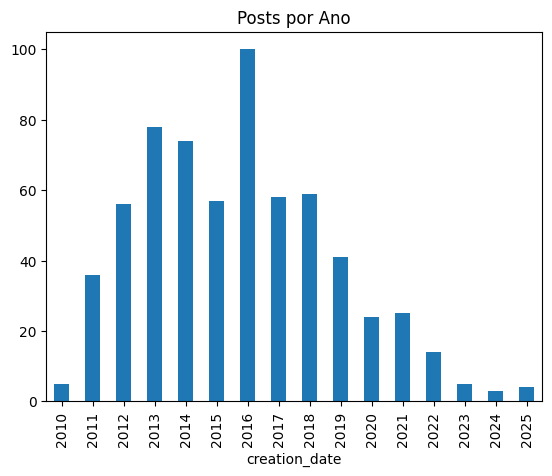

In [20]:
df_mv = df.sort_values(by='view_count', ascending=False)

df['creation_date'] = pd.to_datetime(df['creation_date'])
df['last_activity_date'] = pd.to_datetime(df['last_activity_date'])

contagem_por_ano = df.groupby(df['creation_date'].dt.year).size()
contagem_por_ano.plot.bar(title='Posts por Ano')

<Axes: title={'center': 'last_activity por Ano'}, xlabel='last_activity_date'>

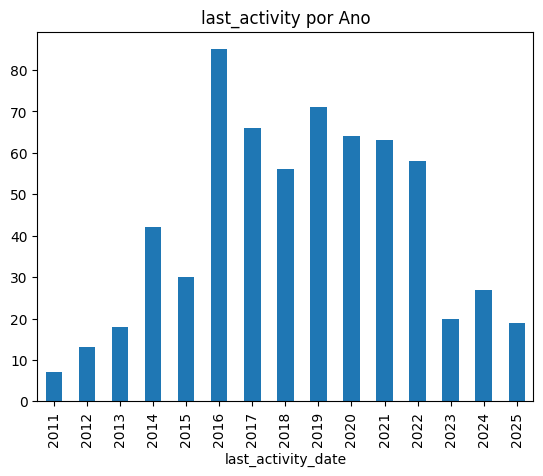

In [21]:
contagem_por_ano = df.groupby(df['last_activity_date'].dt.year).size()
contagem_por_ano.plot.bar(title='last_activity por Ano')

<Axes: title={'center': 'Score por creation_date'}, xlabel='creation_date'>

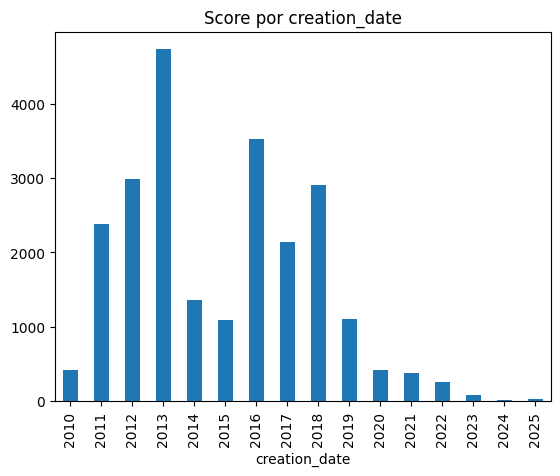

In [22]:
contagem_por_ano = df.groupby(df['creation_date'].dt.year)['score'].sum()
contagem_por_ano.plot.bar(title='Score por creation_date')

<Axes: title={'center': 'Média de views por ano'}, xlabel='creation_date'>

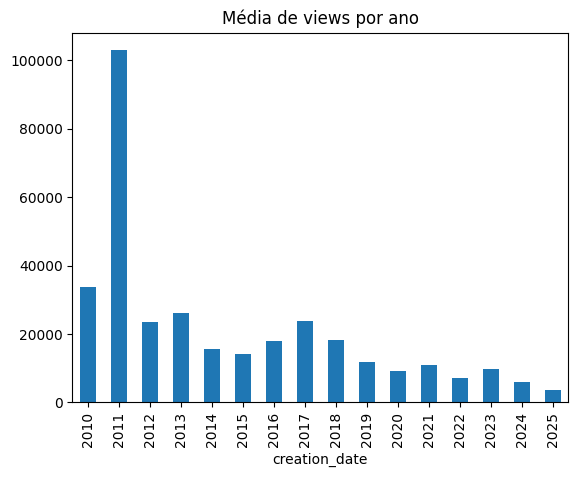

In [23]:
views_por_ano = df.groupby(df['creation_date'].dt.year)['view_count'].mean()
views_por_ano.plot.bar(title='Média de views por ano')

In [24]:
df[df['type'] == 'question'].shape

(639, 18)